In [5]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# Number of users
n_users = 10000

# Random assignment
variants = np.random.choice(
    ['A', 'B'],
    size=n_users,
    p=[0.5, 0.5]
)

clicks = []

for variant in variants:

    if variant == 'A':
        click = np.random.binomial(1, 0.10)

    else:
        click = np.random.binomial(1, 0.12)

    clicks.append(click)

df = pd.DataFrame({
    'user_id': range(1, n_users+1),
    'variant': variants,
    'click': clicks
})

df.head()

df['click'].value_counts()

,count
click,
0,8859
1,1141


In [6]:
df.groupby('variant')['click'].mean()*100

,click
variant,
A,10.224586
B,12.632006


In [7]:
df['variant'].value_counts()

,count
variant,
A,5076
B,4924


In [8]:
df[df['click']==1].head(10)

,user_id,variant,click
12,13,B,1
22,23,A,1
26,27,A,1
27,28,B,1
31,32,A,1
33,34,B,1
40,41,A,1
49,50,A,1
52,53,B,1
69,70,B,1


In [9]:
df[df['click']==0].head(10)

,user_id,variant,click
0,1,A,0
1,2,B,0
2,3,B,0
3,4,B,0
4,5,A,0
5,6,A,0
6,7,A,0
7,8,B,0
8,9,B,0
9,10,B,0


In [10]:
df.shape

df['click'].value_counts()

df.groupby('variant')['click'].mean()*100

,click
variant,
A,10.224586
B,12.632006


In [11]:
import pandas as pd
import numpy as np

from statsmodels.stats.proportion import proportions_ztest

In [12]:
summary = df.groupby('variant').agg(
    impressions=('click', 'count'),
    clicks=('click', 'sum')
)

summary

,impressions,clicks
variant,,
A,5076,519
B,4924,622


In [14]:
clicks = summary['clicks'].values

impressions = summary['impressions'].values

print("Clicks:", clicks)
print("Impressions:", impressions)

Clicks: [519 622]
Impressions: [5076 4924]


In [15]:
z_stat, p_value = proportions_ztest(
    count=clicks,
    nobs=impressions
)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: -3.7856159947967467
P Value: 0.0001533282922100967


In [16]:
alpha = 0.05

if p_value < alpha:
    print("✅ Statistically Significant")
    print("Reject Null Hypothesis")
else:
    print("❌ Not Significant")
    print("Fail to Reject Null Hypothesis")

✅ Statistically Significant
Reject Null Hypothesis


In [17]:
ctr_a = summary.loc['A','clicks'] / summary.loc['A','impressions']

ctr_b = summary.loc['B','clicks'] / summary.loc['B','impressions']

lift = ((ctr_b - ctr_a) / ctr_a) * 100

print(f"Lift = {lift:.2f}%")

Lift = 23.55%


CONFIDENCE LEVEL

In [19]:
from statsmodels.stats.proportion import proportion_confint

In [20]:
a_clicks = summary.loc['A','clicks']
a_total = summary.loc['A','impressions']

ci_a = proportion_confint(
    count=a_clicks,
    nobs=a_total,
    alpha=0.05,
    method='normal'
)

print(ci_a)

(0.09391118415402983, 0.11058054161429168)


In [21]:
b_clicks = summary.loc['B','clicks']
b_total = summary.loc['B','impressions']

ci_b = proportion_confint(
    count=b_clicks,
    nobs=b_total,
    alpha=0.05,
    method='normal'
)

print(ci_b)

(0.11704105974724809, 0.13559907022838147)


In [22]:
print(
    f"Variant A CTR = {ctr_a*100:.2f}% "
    f"(95% CI: {ci_a[0]*100:.2f}% - {ci_a[1]*100:.2f}%)"
)

print(
    f"Variant B CTR = {ctr_b*100:.2f}% "
    f"(95% CI: {ci_b[0]*100:.2f}% - {ci_b[1]*100:.2f}%)"
)

Variant A CTR = 10.22% (95% CI: 9.39% - 11.06%)
Variant B CTR = 12.63% (95% CI: 11.70% - 13.56%)


In [25]:
import matplotlib.pyplot as plt

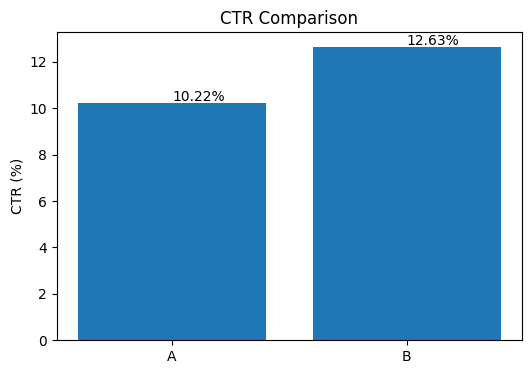

In [26]:
variants = ['A','B']
ctrs = [ctr_a*100, ctr_b*100]

plt.figure(figsize=(6,4))
plt.bar(variants, ctrs)

plt.title("CTR Comparison")
plt.ylabel("CTR (%)")

for i,v in enumerate(ctrs):
    plt.text(i,v+0.1,f"{v:.2f}%")

plt.show()

In [27]:
from statsmodels.stats.proportion import proportion_confint

a_clicks = summary.loc['A','clicks']
a_total = summary.loc['A','impressions']

b_clicks = summary.loc['B','clicks']
b_total = summary.loc['B','impressions']

ci_a = proportion_confint(
    count=a_clicks,
    nobs=a_total,
    alpha=0.05,
    method='normal'
)

ci_b = proportion_confint(
    count=b_clicks,
    nobs=b_total,
    alpha=0.05,
    method='normal'
)

print(
    f"Variant A CTR = {(a_clicks/a_total)*100:.2f}% "
    f"(95% CI: {ci_a[0]*100:.2f}% - {ci_a[1]*100:.2f}%)"
)

print(
    f"Variant B CTR = {(b_clicks/b_total)*100:.2f}% "
    f"(95% CI: {ci_b[0]*100:.2f}% - {ci_b[1]*100:.2f}%)"
)

Variant A CTR = 10.22% (95% CI: 9.39% - 11.06%)
Variant B CTR = 12.63% (95% CI: 11.70% - 13.56%)


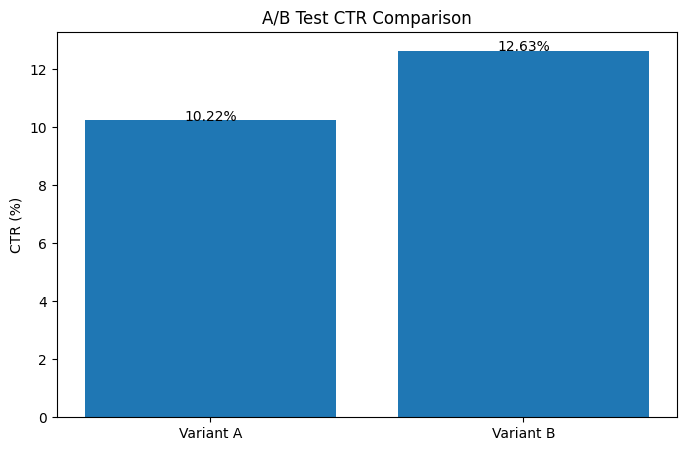

In [31]:
import matplotlib.pyplot as plt

ctr_a = a_clicks/a_total*100
ctr_b = b_clicks/b_total*100

plt.figure(figsize=(8,5))

bars = plt.bar(
    ['Variant A','Variant B'],
    [ctr_a, ctr_b]
)

plt.ylabel('CTR (%)')
plt.title('A/B Test CTR Comparison')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [32]:
from statsmodels.stats.proportion import proportions_ztest

devices = df['device'].unique()

for device in devices:

    temp = df[df['device']==device]

    summary_device = temp.groupby('variant').agg(
        impressions=('click','count'),
        clicks=('click','sum')
    )

    clicks = summary_device['clicks'].values
    impressions = summary_device['impressions'].values

    z,p = proportions_ztest(
        clicks,
        impressions
    )

    print("\nDevice:",device)
    print("P-value:",round(p,4))

    if p < 0.05:
        print("Significant")
    else:
        print("Not Significant")

KeyError: 'device'

In [33]:
import numpy as np

n_users = len(df)

df['device'] = np.random.choice(
    ['Mobile','Desktop','Tablet'],
    size=n_users,
    p=[0.7,0.2,0.1]
)

df['country'] = np.random.choice(
    ['India','USA','UK'],
    size=n_users,
    p=[0.6,0.25,0.15]
)

df['user_type'] = np.random.choice(
    ['New','Returning'],
    size=n_users,
    p=[0.4,0.6]
)

df.head()

,user_id,variant,click,device,country,user_type
0,1,A,0,Desktop,USA,New
1,2,B,0,Mobile,India,New
2,3,B,0,Mobile,UK,New
3,4,B,0,Mobile,India,New
4,5,A,0,Mobile,India,New


In [34]:
from statsmodels.stats.proportion import proportions_ztest

devices = df['device'].unique()

for device in devices:

    temp = df[df['device']==device]

    summary_device = temp.groupby('variant').agg(
        impressions=('click','count'),
        clicks=('click','sum')
    )

    clicks = summary_device['clicks'].values
    impressions = summary_device['impressions'].values

    z,p = proportions_ztest(
        clicks,
        impressions
    )

    print("\nDevice:",device)
    print("P-value:",round(p,4))

    if p < 0.05:
        print("Significant")
    else:
        print("Not Significant")


Device: Desktop
P-value: 0.7876
Not Significant

Device: Mobile
P-value: 0.0003
Significant

Device: Tablet
P-value: 0.0421
Significant


In [35]:
countries = df['country'].unique()

for country in countries:

    temp = df[df['country']==country]

    summary_country = temp.groupby('variant').agg(
        impressions=('click','count'),
        clicks=('click','sum')
    )

    clicks = summary_country['clicks'].values
    impressions = summary_country['impressions'].values

    z,p = proportions_ztest(
        clicks,
        impressions
    )

    print("\nCountry:",country)
    print("P-value:",round(p,4))

    if p < 0.05:
        print("Significant")
    else:
        print("Not Significant")


Country: USA
P-value: 0.0362
Significant

Country: India
P-value: 0.018
Significant

Country: UK
P-value: 0.0197
Significant


In [37]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.8 MB/s eta 0:00:00


In [39]:
import streamlit as st
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

st.title("A/B Testing Simulator")

uploaded_file = st.file_uploader(
    "Upload CSV",
    type=['csv']
)

if uploaded_file:

    df = pd.read_csv(uploaded_file)

    summary = df.groupby('variant').agg(
        impressions=('click','count'),
        clicks=('click','sum')
    )

    ctr = (
        summary['clicks']
        /
        summary['impressions']
        *100
    )

    st.subheader("CTR Comparison")
    st.dataframe(summary)

    clicks = summary['clicks'].values
    impressions = summary['impressions'].values

    z,p = proportions_ztest(
        clicks,
        impressions
    )

    st.metric(
        "P-value",
        round(p,6)
    )

    if p < 0.05:
        st.success(
            "Statistically Significant"
        )
    else:
        st.error(
            "Not Significant"
        )

    st.bar_chart(ctr)

2026-06-13 10:24:58.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:24:58.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [40]:
print(df.columns)

Index(['user_id', 'variant', 'click', 'device', 'country', 'user_type'], dtype='object')


In [41]:
import matplotlib.pyplot as plt

ctr_summary = (
    df.groupby('variant')
      .agg(
          impressions=('click','count'),
          clicks=('click','sum')
      )
)

ctr_summary['CTR'] = (
    ctr_summary['clicks']
    /
    ctr_summary['impressions']
    *100
)

ctr_summary

,impressions,clicks,CTR
variant,,,
A,5076,519,10.224586
B,4924,622,12.632006


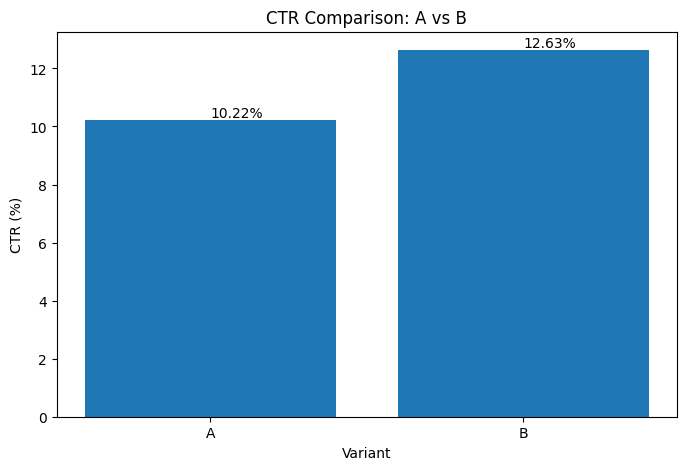

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    ctr_summary.index,
    ctr_summary['CTR']
)

plt.title("CTR Comparison: A vs B")
plt.ylabel("CTR (%)")
plt.xlabel("Variant")

for i,v in enumerate(ctr_summary['CTR']):
    plt.text(i,v+0.1,f"{v:.2f}%")

plt.show()

In [45]:
country_ctr = (
    df.groupby(['country','variant'])
      .agg(
          clicks=('click','sum'),
          impressions=('click','count')
      )
      .reset_index()
)

country_ctr['CTR'] = (
    country_ctr['clicks']
    /
    country_ctr['impressions']
    *100
)

country_ctr

,country,variant,clicks,impressions,CTR
0,India,A,325,3063,10.610513
1,India,B,369,2937,12.563841
2,UK,A,70,729,9.602195
3,UK,B,104,773,13.454075
4,USA,A,124,1284,9.657321
5,USA,B,149,1214,12.273476


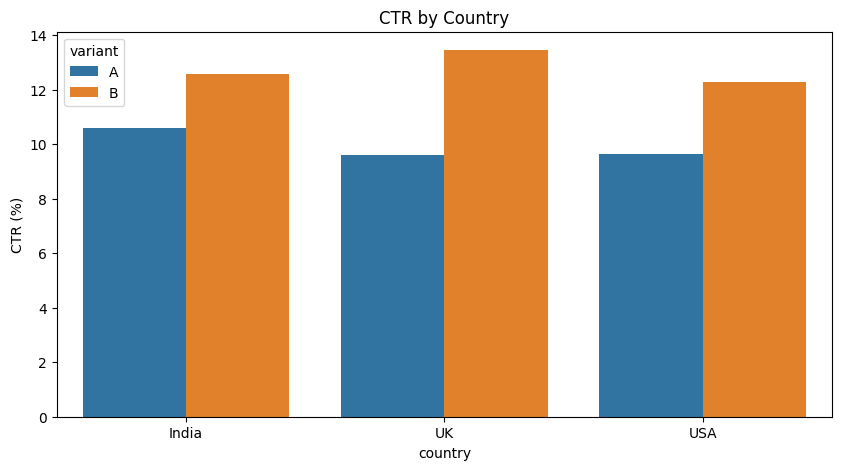

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=country_ctr,
    x='country',
    y='CTR',
    hue='variant'
)

plt.title("CTR by Country")
plt.ylabel("CTR (%)")

plt.show()

In [47]:
from statsmodels.stats.proportion import proportion_confint

In [48]:
a_clicks = summary.loc['A','clicks']
a_total = summary.loc['A','impressions']

b_clicks = summary.loc['B','clicks']
b_total = summary.loc['B','impressions']

ctrs = [
    a_clicks/a_total*100,
    b_clicks/b_total*100
]

ci_a = proportion_confint(
    a_clicks,
    a_total
)

ci_b = proportion_confint(
    b_clicks,
    b_total
)

In [49]:
lower = [
    ctrs[0]-ci_a[0]*100,
    ctrs[1]-ci_b[0]*100
]

upper = [
    ci_a[1]*100-ctrs[0],
    ci_b[1]*100-ctrs[1]
]

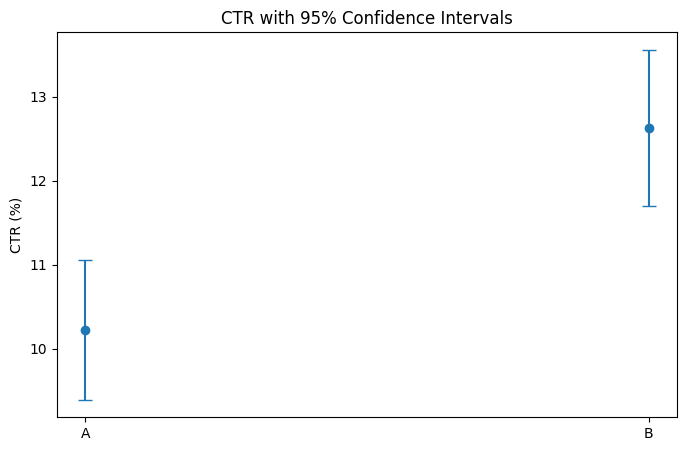

In [50]:
plt.figure(figsize=(8,5))

plt.errorbar(
    ['A','B'],
    ctrs,
    yerr=[lower,upper],
    fmt='o',
    capsize=5
)

plt.ylabel('CTR (%)')
plt.title('CTR with 95% Confidence Intervals')

plt.show()

In [51]:
import streamlit as st
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

st.set_page_config(
    page_title="A/B Testing Simulator",
    layout="wide"
)

st.title("📊 A/B Testing Simulator")

uploaded_file = st.file_uploader(
    "Upload Experiment Data",
    type=["csv"]
)

if uploaded_file:

    df = pd.read_csv(uploaded_file)

    summary = (
        df.groupby('variant')
        .agg(
            impressions=('click','count'),
            clicks=('click','sum')
        )
    )

    summary['CTR (%)'] = (
        summary['clicks']
        /
        summary['impressions']
        *100
    )

    st.subheader("CTR Summary")
    st.dataframe(summary)

    clicks = summary['clicks'].values
    impressions = summary['impressions'].values

    z_stat,p_value = proportions_ztest(
        count=clicks,
        nobs=impressions
    )

    st.subheader("Statistical Test")

    col1,col2 = st.columns(2)

    with col1:
        st.metric(
            "Z Statistic",
            round(z_stat,4)
        )

    with col2:
        st.metric(
            "P Value",
            round(p_value,6)
        )

    if p_value < 0.05:
        st.success(
            "✅ Statistically Significant"
        )
    else:
        st.error(
            "❌ Not Significant"
        )

    st.subheader("CTR Comparison")

    st.bar_chart(
        summary['CTR (%)']
    )

2026-06-13 10:40:26.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.866 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:40:26.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [52]:
# Colab cell
import streamlit as st

st.title("A/B Testing Simulator")

2026-06-13 10:41:57.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:41:57.803 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 10:41:57.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [53]:
df.to_csv("ab_testing_data.csv", index=False)

In [54]:
from google.colab import files
files.download("ab_testing_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>